# 🚀 Personalização com IA: Transformando Dados em Experiências Relevantes

Nesta palestra, exploraremos como a Inteligência Artificial pode elevar a experiência do cliente, transformando personalização de um diferencial em uma expectativa.

Veremos a aplicação prática de modelos clássicos de machine learning trabalhando em conjunto com IA generativa para criar uma personalização em tempo real. Bora aprender juntos e juntas? 🎈

---

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)

import json

## 📊 2. A Matéria-Prima: Carregamento dos Dados

Nosso ponto de partida é um conjunto de dados de e-commerce, o `ecommerce_hiperpersonalizacao_catalogo.csv`. Cada linha aqui representa uma sessão de usuário e suas interações em nosso site.

É a partir desses dados brutos que a IA começará a *entender* o comportamento do cliente e a *transformar dados em experiências relevantes*. 💡

Percebemos que o arquivo CSV poderia ter algumas linhas 'malformadas', então usamos `engine='python'` e `on_bad_lines='skip'` para garantir que o carregamento seja suave e robusto, como faríamos em um ambiente de produção. ✨

## 📦 1. Preparando o Terreno: Importação de Bibliotecas

Antes de mergulharmos nos dados e modelos, precisamos de nossas ferramentas! Esta célula importa todas as bibliotecas Python essenciais para construir nosso sistema de personalização. Elas nos ajudarão a carregar dados, pré-processar informações, construir modelos de Machine Learning e até mesmo interagir com IAs Generativas. 🛠️

In [2]:
df = pd.read_csv('ecommerce_hiperpersonalizacao_catalogo.csv', engine='python', on_bad_lines='skip')
pd.set_option("display.max_columns", None)
df.head()

,cliente_id,idade,tipo_dispositivo,origem,categoria_principal,paginas_visualizadas,produtos_visualizados,cliques_produto,realizou_busca,qtd_buscas,produtos_carrinho,visitou_checkout,tempo_sessao_min,compras_anteriores,sessoes_anteriores,dias_ultima_compra,recebeu_campanha,utilizou_cupom,preco_medio_produto,valor_carrinho,converteu,log_acesso,qtd_eventos_30d,qtd_categorias_interesse_30d,produto_maior_interesse
0,2,46,mobile,organico,esportes,4,4,2,1,2,0,0,3.24,3,7,2,0,1,194.78,0.00,1,"[{""timestamp"": ""2026-07-19 07:07:00"", ""produto...",21,6,ActivePack
1,2,45,desktop,organico,casa,11,6,4,0,0,0,1,3.64,3,5,11,0,0,103.04,0.00,0,"[{""timestamp"": ""2026-07-17 07:37:00"", ""produto...",19,4,HomeBrew
2,2,35,mobile,direto,eletronicos,5,2,2,0,0,1,0,1.45,2,6,100,0,0,98.30,100.54,1,"[{""timestamp"": ""2026-07-18 05:59:00"", ""produto...",21,3,EchoMini
3,3,20,desktop,organico,livros,8,5,6,1,2,0,0,9.01,4,4,9,1,0,48.76,0.00,0,"[{""timestamp"": ""2026-07-18 06:14:00"", ""produto...",28,5,Gestão sem Ruído
4,3,22,mobile,google_ads,casa,6,7,3,1,3,0,0,8.37,0,5,17,0,0,51.71,0.00,1,"[{""timestamp"": ""2026-07-18 01:36:00"", ""produto...",27,6,HomeBrew


## 🔍 3. Entendendo o Volume: Visão Geral dos Dados

Com a IA, a escala importa! Esta célula nos mostra o tamanho do nosso conjunto de dados: o número de linhas (clientes/sessões) e colunas (características).

Um grande volume de dados bem estruturados é fundamental para treinar modelos de Machine Learning eficazes. 📈

In [3]:
print("Linhas:", df.shape[0])
print("Colunas:", df.shape[1])

Linhas: 20000
Colunas: 25


## 🎯 4. O Nosso Objetivo: Analisando a Variável `converteu`

Em personalização, frequentemente queremos prever uma ação específica. Aqui, estamos interessados em saber se um cliente `converteu` (ou seja, realizou uma compra).

Esta célula nos mostra a distribuição dessa variável. É crucial entender o equilíbrio entre clientes que converteram e os que não converteram para garantir que nosso modelo aprenda de forma justa. ⚖️

In [4]:
df["converteu"].value_counts(normalize=True)

,proportion
converteu,
1,0.74025
0,0.25975


## 🧩 5. Separando o Joio do Trigo: Features e Target

Para o nosso modelo de IA, precisamos definir claramente o que são as 'características' (ou `features`) que ele vai usar para aprender e qual é o 'alvo' (`target`) que ele deve prever.

*   **`features`**: São todas as informações comportamentais e demográficas que coletamos sobre o cliente (idade, tipo de dispositivo, páginas visualizadas, etc.). Essas são as bases da nossa **análise comportamental**. 🧠
*   **`target`**: É a variável que queremos prever, neste caso, se o cliente `converteu` ou não. Com isso, podemos criar **modelos de recomendação** mais precisos.

In [5]:
target = "converteu"

features = [
    "idade",
    "tipo_dispositivo",
    "origem",
    "categoria_principal",
    "paginas_visualizadas",
    "produtos_visualizados",
    "cliques_produto",
    "realizou_busca",
    "qtd_buscas",
    "produtos_carrinho",
    "visitou_checkout",
    "tempo_sessao_min",
    "compras_anteriores",
    "sessoes_anteriores",
    "dias_ultima_compra",
    "recebeu_campanha",
    "utilizou_cupom",
    "preco_medio_produto",
    "valor_carrinho",
    "qtd_eventos_30d",
    "qtd_categorias_interesse_30d"
]

X = df[features]
y = df[target]

## ✅ 6. Qualidade dos Dados: Verificação de Nulos no Target

Um passo fundamental em qualquer projeto de dados é verificar a qualidade. Nesta célula, confirmamos que não há valores ausentes (nulos) na nossa variável `target` (`converteu`).

Isso é vital porque dados ausentes podem comprometer o treinamento do modelo e levar a previsões imprecisas. 🧹

In [22]:
print("Contagem de valores nulos nas features em X antes da limpeza:")
print(X.isnull().sum())

Contagem de valores nulos nas features em X antes da limpeza:
idade                           0
tipo_dispositivo                0
origem                          0
categoria_principal             0
paginas_visualizadas            0
produtos_visualizados           0
cliques_produto                 0
realizou_busca                  0
qtd_buscas                      0
produtos_carrinho               0
visitou_checkout                0
tempo_sessao_min                0
compras_anteriores              0
sessoes_anteriores              0
dias_ultima_compra              0
recebeu_campanha                0
utilizou_cupom                  0
preco_medio_produto             0
valor_carrinho                  0
qtd_eventos_30d                 0
qtd_categorias_interesse_30d    0
dtype: int64


In [6]:
print("Contagem de valores nulos na coluna 'converteu' (y) antes da limpeza:")
print(y.isnull().sum())

Contagem de valores nulos na coluna 'converteu' (y) antes da limpeza:
0


## 🧪 7. Preparação para o Teste: Divisão em Treino e Teste

Para garantir que nosso modelo de IA seja robusto e generalize bem para dados `não vistos` (o que é crucial em personalização em tempo real!), dividimos nosso dataset em:

*   **`X_train`, `y_train`**: Usados para *treinar* o modelo. É aqui que ele aprende os padrões.
*   **`X_test`, `y_test`**: Usados para *avaliar* o modelo. Esses dados são mantidos completamente separados e o modelo só os vê depois de treinado, simulando um cenário real.

O `random_state=42` garante que essa divisão seja *reproduzível*. 🔄

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

## 🏷️ 8. Categorizando Nossas Features: Numéricas e Categóricas

Diferentes tipos de dados exigem diferentes tipos de tratamento. Esta célula separa nossas `features` em dois grupos:

*   **`numericas`**: Dados que representam quantidades (idade, tempo de sessão, preço médio, etc.).
*   **`categoricas`**: Dados que representam categorias (tipo de dispositivo, origem, categoria principal).

Essa distinção é crucial para aplicar as técnicas de pré-processamento corretas e otimizar o desempenho do modelo. 🔢🔤

In [8]:
categoricas = [
    "tipo_dispositivo",
    "origem",
    "categoria_principal"
]

numericas = [
    col for col in features
    if col not in categoricas
]

## ⚙️ 9. O Chef de Cozinha dos Dados: Pipeline de Pré-processamento

Dados brutos raramente estão prontos para serem alimentados em um modelo de Machine Learning. O `ColumnTransformer` e os `Pipelines` nos permitem criar uma 'receita' de pré-processamento que será aplicada consistentemente aos nossos dados:

*   **Imputação (SimpleImputer)**: Preenchemos valores ausentes (nulos) para evitar erros no modelo. Para numéricas, usamos a mediana; para categóricas, o valor mais frequente. 🧹
*   **Escalonamento (StandardScaler)**: Normalizamos as features numéricas para que todas tenham uma escala semelhante, o que ajuda muitos algoritmos de ML a performar melhor. 📏  O StandardScaler padroniza os dados numéricos de um conjunto de dados. Ele subtrai a média dos dados e divide o resultado pelo desvio padrão
*   **One-Hot Encoding (OneHotEncoder)**: Convertemos as features categóricas em um formato numérico que o modelo pode entender, criando novas colunas binárias para cada categoria. ➡️ 0/1

Este `pipeline` garante que a preparação dos dados seja feita de forma organizada e reproduzível, um pilar fundamental para qualquer solução de IA em produção. 🧑‍🍳

In [9]:
preprocessamento = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                (
                    "imputer",
                    SimpleImputer(strategy="median")
                ),
                (
                    "scaler",
                    StandardScaler()
                )
            ]),
            numericas
        ),

        (
            "cat",
            Pipeline([
                (
                    "imputer",
                    SimpleImputer(
                        strategy="most_frequent"
                    )
                ),
                (
                    "onehot",
                    OneHotEncoder(
                        handle_unknown="ignore"
                    )
                )
            ]),
            categoricas
        )
    ]
)

## 🧠 10. O Coração da Predição: Construindo Nosso Modelo XGBoost

Agora que os dados estão prontos, é hora de construir o nosso **modelo de recomendação**! Escolhemos o `XGBoostClassifier`, um algoritmo de Machine Learning poderoso e amplamente utilizado para problemas de classificação. Ele é conhecido por sua eficiência e alta performance.

Nosso modelo será um `Pipeline` completo que combina o pré-processamento de dados que definimos anteriormente com o algoritmo XGBoost. Isso garante que, quando fizermos novas previsões, os dados sejam automaticamente preparados da mesma maneira que foram durante o treinamento. 🔄

In [10]:
modelo = Pipeline(
    steps=[
        (
            "preprocessamento",
            preprocessamento
        ),

        (
            "modelo",
            XGBClassifier(
                n_estimators=300,
                max_depth=6,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="binary:logistic",
                eval_metric="auc",
                random_state=42
            )
        )
    ]
)

## ✨ 11. Visualizando o Modelo: Estrutura do Pipeline

Esta célula simplesmente exibe a estrutura completa do nosso pipeline de Machine Learning. Podemos ver claramente as etapas de pré-processamento e o modelo XGBoost aninhados, confirmando que tudo está configurado como esperado. 🛠️

In [11]:
modelo

Pipeline(steps=[('preprocessamento',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['idade',
                                                   'paginas_visualizadas',
                                                   'produtos_visualizados',
                                                   'cliques_produto',
                                                   'realizou_busca',
                                                   'qtd_buscas',
                                                   'produtos_carrinho',
                                                   'visitou_checkout',
                                                   'tempo_sessao_min',
                                                   'compras_anteriores',
                                                   '...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=None,
                               num_parallel_tree=None, ...))])

## 👨‍🏫 12. O Modelo Aprende: Treinamento!

Esta é a etapa onde a mágica acontece! O método `fit()` treina nosso pipeline (que inclui o pré-processamento e o modelo XGBoost) usando os dados de `treino` (`X_train` e `y_train`).

Durante este processo, o modelo 'aprende' os padrões e relações entre as `features` e a variável `target` (`converteu`), ajustando seus pesos e parâmetros internos para fazer as melhores previsões possíveis. 📚

In [12]:
modelo.fit(X_train, y_train)

Pipeline(steps=[('preprocessamento',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['idade',
                                                   'paginas_visualizadas',
                                                   'produtos_visualizados',
                                                   'cliques_produto',
                                                   'realizou_busca',
                                                   'qtd_buscas',
                                                   'produtos_carrinho',
                                                   'visitou_checkout',
                                                   'tempo_sessao_min',
                                                   'compras_anteriores',
                                                   '...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=None,
                               num_parallel_tree=None, ...))])

## 🔮 13. O Modelo Prevê: Gerando Predições e Probabilidades

Com o modelo treinado, podemos agora usá-lo para fazer previsões sobre os dados de `teste` (`X_test`), que ele nunca viu antes.

*   **`y_pred`**: A classe prevista (0 para não converteu, 1 para converteu).
*   **`y_proba`**: A *probabilidade* de o cliente converter. Este é o **sinal de propensão** que será usado para alimentar a IA Generativa.

Essa propensão é a base para a **personalização em tempo real**, permitindo-nos focar nos clientes com maior chance de conversão. 🎯

In [13]:
y_pred = modelo.predict(X_test)

y_proba = modelo.predict_proba(X_test)[:, 1]

## 📊 14. Dando uma Espiadinha: As Primeiras Probabilidades

Esta célula exibe um trecho do array `y_proba`, mostrando algumas das probabilidades de conversão calculadas pelo nosso modelo para os clientes no conjunto de teste. São esses números que representam a 'propensão' e guiarão nossas ações personalizadas. 💯

In [14]:
y_proba

array([0.77751553, 0.76982856, 0.83939606, ..., 0.94000393, 0.95064926,
       0.6477556 ], dtype=float32)

## 📉 15. Avaliando a Performance: Curva ROC

A Curva ROC (Receiver Operating Characteristic) é uma ferramenta visual crucial para avaliar o desempenho de nosso modelo de classificação. Ela nos ajuda a entender quão bem o modelo consegue distinguir entre as classes (clientes que convertem vs. clientes que não convertem).

*   Comparamos a curva para o conjunto de **treino** (`y_proba_train`) e **teste** (`y_proba`).
*   Uma curva mais próxima do canto superior esquerdo indica um modelo com melhor desempenho.
*   A linha tracejada (`plot_chance_level`) representa um classificador aleatório (50% de chance), e esperamos que nosso modelo esteja sempre acima dela.

Esta análise é parte fundamental dos **modelos de recomendação**, garantindo que as previsões sejam confiáveis. 📉📊

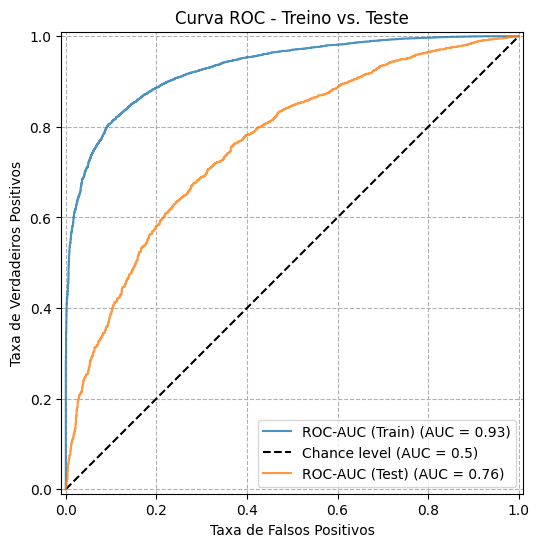

In [15]:
y_proba_train = modelo.predict_proba(X_train)[:, 1]

fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_train,
    y_proba_train,
    name="ROC-AUC (Train)",
    ax=ax,
    plot_chance_level=True,
    alpha=0.8
)

RocCurveDisplay.from_predictions(
    y_test,
    y_proba,
    name="ROC-AUC (Test)",
    ax=ax,
    plot_chance_level=False,
    alpha=0.8
)

plt.title("Curva ROC - Treino vs. Teste")
plt.xlabel("Taxa de Falsos Positivos")
plt.ylabel("Taxa de Verdadeiros Positivos")
plt.grid(linestyle='--')
plt.show()

## 💾 16. Preservando o Conhecimento: Salvando o Modelo

Depois de todo o trabalho de treinamento, precisamos salvar nosso modelo! O `joblib.dump()` nos permite serializar o pipeline completo (pré-processamento + modelo) em um arquivo (`propensity_model.joblib`).

Este arquivo pode então ser carregado em qualquer aplicação (como o Streamlit) para fazer previsões sem a necessidade de retreinar o modelo. Isso é essencial para a **implantação** e **personalização em tempo real**, garantindo que o modelo esteja sempre disponível quando necessário. 📦

In [16]:
import joblib

# Salva o pipeline completo (preprocessamento + modelo) para uso posterior
joblib.dump(modelo, 'propensity_model.joblib')

print("Modelo salvo como 'propensity_model.joblib'")

Modelo salvo como 'propensity_model.joblib'


## 🤖 17. Desbloqueando a Criatividade: Configuração da IA Generativa

Agora entramos no reino da **Inteligência Artificial Generativa**! Para integrar a capacidade do Gemini de criar narrativas personalizadas, precisamos configurar nosso ambiente.

Esta seção do notebook foca em:
*   **Instalar o SDK do Google Gemini**: A ponte entre nosso código Python e o poderoso modelo Gemini na nuvem. 🌉
*   **Gerenciar Chaves de API**: A segurança é primordial! As chaves de API são armazenadas e acessadas de forma segura (`userdata.get`) para autenticar nossas requisições ao Gemini, seguindo as melhores práticas de **privacidade e governança**. 🔑

## IA Generativa: narrativa hiperpersonalizada da próxima compra

Nesta etapa, combinamos o **sinal preditivo do modelo clássico** com o histórico recente armazenado em `log_acesso`.

In [17]:
# Instalação do SDK oficial do Google Gemini
#!pip -q install -U google-genai


## 🛠️ 18. Garantindo a Compatibilidade: Instalação de `google-auth`

Por vezes, diferentes bibliotecas têm requisitos específicos de versão para seus componentes. Aqui, garantimos que a versão do `google-auth` (que lida com autenticação para os serviços Google) seja compatível com o ambiente do Colab e outras bibliotecas. Este é um exemplo prático dos **desafios de governança** de dependências em projetos de IA. 🧩

In [18]:
# Instala a versão específica de google-auth requerida por google-colab
#!pip install google-auth==2.49.0

# Após a execução, você pode precisar reiniciar o ambiente de execução (Runtime -> Restart runtime)
# para que a nova versão do pacote seja carregada corretamente.

## 💬 19. A Voz da Personalização: Função `live_narrative`

Esta é a estrela da nossa **personalização em tempo real**! A função `live_narrative` é a responsável por traduzir o `sinal de propensão` do nosso modelo clássico e o `histórico de comportamento` do cliente em uma narrativa envolvente e personalizada. ✨

**Como funciona:**
1.  **Contexto do Cliente**: Recebe uma linha de dados do cliente (`row`), o `produto candidato` e a `probabilidade de conversão`.
2.  **Tom Adaptável**: Ajusta o *tom* da mensagem com base na propensão: mais confiante para alta propensão, mais consultivo para baixa. 🗣️
3.  **Prompt Estruturado**: Constrói um `prompt` detalhado para o Gemini, incluindo todas as informações relevantes do cliente (categoria, eventos recentes, etc.).
4.  **Regras Claras**: Impõe regras rigorosas para o Gemini (não inventar, não revelar dados técnicos, etc.), um exemplo de **ética e governança** em IA Generativa.
5.  **Geração com Gemini**: Envia o `prompt` para o modelo Gemini e recebe uma resposta de texto natural.

Essa função é a ponte entre a **análise comportamental** e a **experiência do usuário**, materializando a promessa de **personalização em tempo real**. ✍️

In [19]:
from pathlib import Path
import json
import os

# Certifique-se de que `genai` esteja importado
# (isso já está feito em células anteriores do notebook)
from google import genai
from google.colab import userdata # Adicionado para acessar secrets diretamente na função

# Simulação do carregamento de genai_config para esta célula
# Em um ambiente de produção, esta configuração seria carregada de forma robusta
MODELS = Path('./') # Ajuste o caminho se 'genai_config.json' não estiver na raiz

def load_artifacts_for_notebook():
    config_path = MODELS / "genai_config.json"
    config = {}
    if config_path.exists():
        config = json.loads(config_path.read_text(encoding="utf-8"))
    return config

genai_config = load_artifacts_for_notebook()

def parse_log(raw):
    """Parses a raw log string into a list of events."""
    try:
        return json.loads(raw)
    except Exception:
        return []

def live_narrative(
    row,
    product,
    probability
):
    """Gera uma narrativa ao vivo usando o modelo Gemini, espelhando a lógica do app."""
    api_key = userdata.get("GEMINI_API_KEY") # Alterado para usar userdata.get

    if not api_key or genai is None:
        print("API key do Gemini não encontrada ou SDK não disponível.")
        return None

    events = parse_log(
        row["log_acesso"]
    )[-12:]

    if probability >= 0.80:
        tone = """
A propensão de conversão é alta.

Seja mais confiante e orientado à conversão.
Apresente o produto como uma escolha bastante relevante
para este momento.

Inclua uma chamada para ação clara.

Não seja agressivo, apelativo ou manipulativo.
"""

    else:

        tone = """
A propensão de conversão ainda não é alta.

Use um tom consultivo, leve e exploratório.

Apresente o produto como uma possibilidade relevante,
sem pressionar o cliente a comprar.

Não use chamadas de ação agressivas.
"""

    prompt = f"""
Você é o concierge de uma experiência
de e-commerce premium.

Explique ao cliente por que o produto
\"{product}\" está sendo destacado neste momento.

Sinais observados:

Categoria:
{row["categoria_principal"]}

Eventos nos últimos 30 dias:
{row["qtd_eventos_30d"]}

Categorias exploradas:
{row["qtd_categorias_interesse_30d"]}

Propensão estimada:
{probability:.0%}

Histórico recente:
{json.dumps(events, ensure_ascii=False)}

TOM:

{tone}

REGRAS:

- O produto candidato é fixo.
- Não troque o produto.
- Use somente fatos observados.
- Não invente informações.
- Não mencione algoritmo.
- Não mencione modelo.
- Não mencione Gemini.
- Não mencione JSON.
- Não mencione dados pessoais.
- Português do Brasil.
- Exatamente duas frases.
"""

    try:
        # Inicializa o cliente Gemini internamente, como no app
        client_internal = genai.Client(
            api_key=api_key
        )

        response = client_internal.models.generate_content(
            model=genai_config.get(
                "model",
                "gemini-3.6-flash" # Mantém o modelo mais atualizado como fallback
            ),
            contents=prompt,
        )

        return (
            response.text or ""
        ).strip()

    except Exception as e:
        print(f"Erro ao gerar narrativa: {e}")
        return None

## 🚀 20. Demonstração Completa: Do Dado à Narrativa Personalizada

Esta célula amarra tudo! Aqui, realizamos uma demonstração de ponta a ponta do nosso sistema de personalização:

1.  **Seleção do Cliente**: Escolhemos um cliente aleatório do nosso conjunto de teste (`X_test`) para garantir que estamos avaliando o modelo em dados `não vistos`. 🕵️
2.  **Extração de Dados**: Recuperamos todas as informações detalhadas do cliente selecionado do DataFrame original (`df`). 📋
3.  **Cálculo da Propensão**: Alimentamos os dados do cliente no nosso `modelo` de Machine Learning para obter a **probabilidade de conversão** (`probabilidade_exemplo`). 📊
4.  **Definição do Produto Candidato**: Identificamos o produto de maior interesse para este cliente. 🛍️
5.  **Geração da Narrativa**: Usamos a função `live_narrative` e o Gemini para criar uma mensagem personalizada, traduzindo o sinal de propensão e o comportamento em linguagem natural. 💬

Este é o clímax da nossa **visão prática** de como a IA entrega **personalização em tempo real**, transformando números em uma experiência de cliente significativa. 🌟

In [20]:
import os
from google import genai
import random

# Obtém a API_KEY (do Colab Secrets ou variável de ambiente)
try:
    from google.colab import userdata
    API_KEY = userdata.get("GEMINI_API_KEY")
except Exception:
    API_KEY = os.getenv("GEMINI_API_KEY")

if not API_KEY:
    raise RuntimeError(
        "API key do Gemini não encontrada. "
        "No Colab, crie o Secret 'GEMINI_API_KEY'. "
        "Localmente, defina a variável de ambiente GEMINI_API_KEY."
    )

# Inicializa o cliente Gemini (permanece para outras operações se necessário, mas live_narrative inicializa internamente)
client = genai.Client(api_key=API_KEY)
print("Cliente Gemini configurado com sucesso.")

# Exemplo de uso da função live_narrative no notebook

# Vamos usar as variáveis já definidas nas células anteriores:
# df, modelo, features, genai_config

# --- NOVO: Seleciona um cliente aleatório do conjunto de testes (X_test) ---
# Pega os 'cliente_id' únicos dos índices correspondentes em df para o X_test
clientes_ids_in_X_test = df.loc[X_test.index, 'cliente_id'].unique()

# Seleciona um cliente_id aleatório deste conjunto
CLIENTE_ID = random.choice(clientes_ids_in_X_test)

print(f"Selecionado cliente_id {CLIENTE_ID} do conjunto de testes para demonstração.")

# Agora, precisamos encontrar UMA linha no X_test que pertence a este CLIENTE_ID
# e usar o *índice dessa linha* para pegar os dados completos do cliente do df.
# Isso garante que o índice que usaremos para .loc em X_test realmente existe em X_test.

# Filtra X_test para o CLIENTE_ID selecionado. Isso nos dá as linhas do X_test para esse cliente.
# O .index contém os índices do df original que estão em X_test para esse cliente.
indices_do_cliente_em_X_test = X_test[df.loc[X_test.index, 'cliente_id'] == CLIENTE_ID].index

# Pega o primeiro índice encontrado para este cliente no X_test
selected_index_from_X_test = indices_do_cliente_em_X_test[0]

# 1. Obter os dados completos do cliente do df, usando o índice garantido de X_test
cliente_exemplo = df.loc[selected_index_from_X_test]

# 2. Calcular a propensão de compra para este cliente usando a linha de X_test correspondente
# A linha correta de X_test é aquela cujo índice acabamos de usar
cliente_X_test_row = X_test.loc[[selected_index_from_X_test]]
probabilidade_exemplo = float(modelo.predict_proba(cliente_X_test_row)[0, 1])

# 3. Definir o produto candidato (já temos 'produto_candidato' definido, vamos reutilizá-lo)
# É importante notar que produto_maior_interesse vem do df completo, que pode ter várias entradas para um cliente
# A melhor prática seria garantir que cliente_exemplo é a linha mais relevante para o 'produto_candidato'.
# No seu código original, 'produto_candidato' é derivado de df_cliente, que é filtrado pelo CLIENTE_ID, mas não
# necessariamente pela linha específica 'cliente_exemplo'. Vamos manter o original por enquanto para evitar mudar a lógica
# de 'produto_candidato', mas é um ponto a ser considerado se as recomendações parecerem inconsistentes.

df_cliente_para_produto_candidato = df[df["cliente_id"] == CLIENTE_ID].copy()
produto_candidato = (
    df_cliente_para_produto_candidato["produto_maior_interesse"]
    .dropna()
    .astype(str)
    .mode()
    .iloc[0]
    if "produto_maior_interesse" in df_cliente_para_produto_candidato.columns
    and not df_cliente_para_produto_candidato["produto_maior_interesse"].dropna().empty
    else "produto mais aderente ao histórico recente"
)
produto_candidato_exemplo = produto_candidato # Reutilizando a variável global


# 4. Gerar a narrativa usando a função live_narrative
narrativa_gerada = live_narrative(
    row=cliente_exemplo,
    product=produto_candidato_exemplo,
    probability=probabilidade_exemplo
)

if narrativa_gerada:
    print(f"\n--- Narrativa Gerada para o Cliente {CLIENTE_ID} ---")
    print(f"Produto Candidato: {produto_candidato_exemplo}")
    print(f"Propensão de Compra: {probabilidade_exemplo:.2%}")
    print("\nNarrativa:")
    print(narrativa_gerada)
    print("--------------------------------------------------")
else:
    print("Não foi possível gerar a narrativa. Verifique o console para mais detalhes (API Key, etc.).")

Cliente Gemini configurado com sucesso.
Selecionado cliente_id 1902 do conjunto de testes para demonstração.



--- Narrativa Gerada para o Cliente 1902 ---
Produto Candidato: ChocoNuts
Propensão de Compra: 51.82%

Narrativa:
Observando sua recente exploração por diferentes categorias e a inclusão de itens de casa e autocuidado ao seu carrinho, o ChocoNuts surge como uma sugestão para o seu momento. Sinta-se à vontade para conhecer essa opção e avaliar se ela complementa as suas seleções com leveza.
--------------------------------------------------


## 🏆 21. Ranking de Oportunidades: Clientes por Propensão

Para otimizar nossas estratégias de personalização, é útil saber quais clientes têm a maior probabilidade de converter. Esta célula cria um DataFrame que lista todos os clientes do nosso conjunto de teste, ordenados pela `probabilidade de conversão` (propensão) do maior para o menor.

*   **`head(10)`**: Mostra os 10 clientes com maior propensão – nossos 'top performers' para ações de personalização.
*   **`tail(10)`**: Mostra os 10 clientes com menor propensão, que podem precisar de uma abordagem diferente ou mais estímulo.

Essa visualização nos ajuda a identificar oportunidades e a planejar ações direcionadas, alinhadas à **análise comportamental** e aos **modelos de recomendação**. 🥇

In [21]:
clientes_e_probabilidades = pd.DataFrame({
    'cliente_id': df.loc[X_test.index, 'cliente_id'],
    'probabilidade_conversao': y_proba
})

clientes_e_probabilidades_ordenadas = clientes_e_probabilidades.sort_values(
    by='probabilidade_conversao', ascending=False
).reset_index(drop=True)

display(clientes_e_probabilidades_ordenadas.head(10))
display(clientes_e_probabilidades_ordenadas.tail(10))

,cliente_id,probabilidade_conversao
0,2584,0.997700
1,3758,0.997227
2,7620,0.997039
3,2732,0.996607
4,1893,0.996381
5,5782,0.996324
6,3461,0.996138
7,2849,0.996136
8,5374,0.996047
9,4269,0.995604


,cliente_id,probabilidade_conversao
4990,6549,0.172799
4991,6708,0.172219
4992,4479,0.171122
4993,4178,0.168386
4994,6388,0.166502
4995,2042,0.160143
4996,3893,0.154334
4997,7852,0.144422
4998,896,0.130835
4999,3883,0.123883
